In [2]:
import pandas as pd
df = pd.read_csv(r'C:\\Users\\Mirnalini\\Crime1.csv',na_values=['NONE'])

In [63]:
df.Resolution.head(10)

0    ARREST, BOOKED
1    ARREST, BOOKED
2    ARREST, BOOKED
3               NaN
4               NaN
5               NaN
6               NaN
7               NaN
8               NaN
9               NaN
Name: Resolution, dtype: object

In [64]:
import numpy as np
df.replace('NaN',np.nan)

,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y,Z
0,5/13/2015 23:53,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,NaN
1,5/13/2015 23:53,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599,2
2,5/13/2015 23:33,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414,3
3,5/13/2015 23:30,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NaN,1500 Block of LOMBARD ST,-122.426995,37.800873,4
4,5/13/2015 23:30,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NaN,100 Block of BRODERICK ST,-122.438738,37.771541,5
5,5/13/2015 23:30,LARCENY/THEFT,GRAND THEFT FROM UNLOCKED AUTO,Wednesday,INGLESIDE,NaN,0 Block of TEDDY AV,-122.403252,37.713431,6
6,5/13/2015 23:30,VEHICLE THEFT,STOLEN AUTOMOBILE,Wednesday,INGLESIDE,NaN,AVALON AV / PERU AV,-122.423327,37.725138,6
7,5/13/2015 23:30,VEHICLE THEFT,STOLEN AUTOMOBILE,Wednesday,BAYVIEW,NaN,KIRKWOOD AV / DONAHUE ST,-122.371274,37.727564,6
8,5/13/2015 23:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,RICHMOND,NaN,600 Block of 47TH AV,-122.508194,37.776601,6
9,5/13/2015 23:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,CENTRAL,NaN,JEFFERSON ST / LEAVENWORTH ST,-122.419088,37.807802,6


C:\Users\Mirnalini\Anaconda3\lib\site-packages\missingno\missingno.py:279: UserWarning: The 'inline' argument has been deprecated, and will be removed in a future version of missingno.
  "The 'inline' argument has been deprecated, and will be removed in a future version "


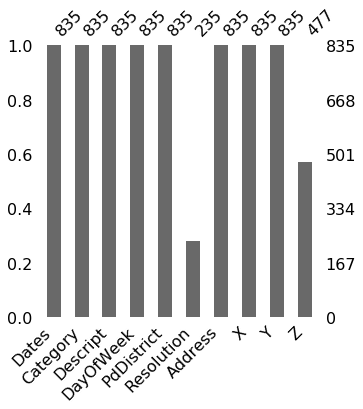

In [65]:

import missingno as ms
ms.bar(df,figsize=(5,5),inline=True)



In [11]:
df['Dates'] = pd.to_datetime(df['Dates'])

In [12]:
df.dtypes

Dates         datetime64[ns]
Category              object
Descript              object
DayOfWeek             object
PdDistrict            object
Resolution            object
Address               object
X                    float64
Y                    float64
Z                     object
dtype: object

In [40]:
df.X.count()

835

In [41]:
len(df)

835

In [56]:

df['x'].kurt()

0.9912475174898132

In [57]:
df['X'].skew()

-1.0975862251308195

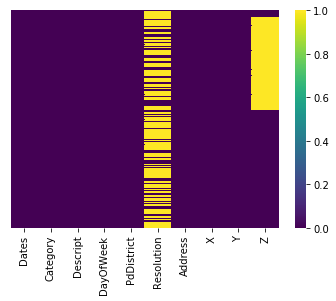

In [66]:
import seaborn as sns
sns.heatmap(df.isnull(),yticklabels=False,cmap='viridis',cbar=True)


In [20]:
df.isnull().sum()

Dates           0
Category        0
Descript        0
DayOfWeek       0
PdDistrict      0
Resolution    600
Address         0
X               0
Y               0
Z             358
dtype: int64

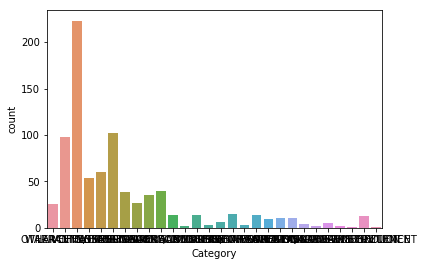

In [36]:
sns.countplot(x=df['Category'])

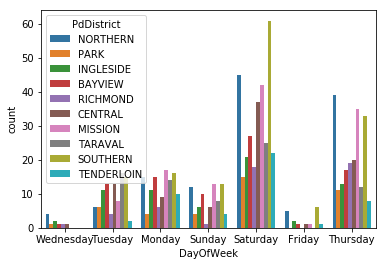

In [41]:
sns.countplot(x='DayOfWeek',data=df,hue='PdDistrict')


In [ ]:
sns.countplot(x='DayOfWeek',data=df)

C:\Users\Mirnalini\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


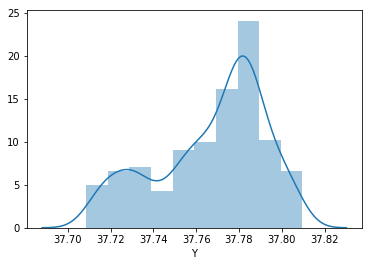

In [50]:
sns.distplot(df['Y'],bins=10,kde=True)

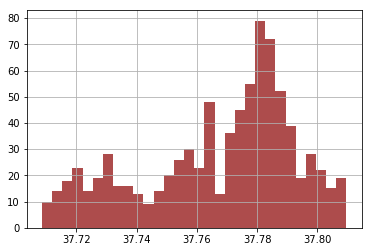

In [56]:
df['Y'].hist(bins=30,alpha=0.7,color='darkred')

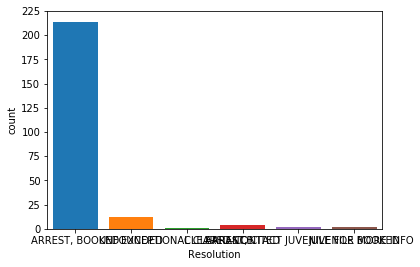

In [72]:
sns.countplot(x='Resolution',data=df,saturation=1.00)

In [18]:
cols = [i for i in df.columns if df[i].isnull().sum()]

In [19]:
print(cols)

['Resolution', 'Z']


In [77]:
miss1 = df.isnull().sum().sort_values(ascending=False)
miss1

#print()

Resolution    600
Z             358
Y               0
X               0
Address         0
PdDistrict      0
DayOfWeek       0
Descript        0
Category        0
Dates           0
dtype: int64

In [79]:

miss2 = (( df.isnull().sum() / len(df) ) * 100).sort_values(ascending=False)
miss2

Resolution    71.856287
Z             42.874251
Y              0.000000
X              0.000000
Address        0.000000
PdDistrict     0.000000
DayOfWeek      0.000000
Descript       0.000000
Category       0.000000
Dates          0.000000
dtype: float64

In [30]:
df.isnull().sum()

Dates           0
Category        0
Descript        0
DayOfWeek       0
PdDistrict      0
Resolution    600
Address         0
X               0
Y               0
Z             358
dtype: int64

In [34]:
( df.Z.isnull().sum() / len(df) ) * 100

42.874251497005986

In [61]:
miss = pd.DataFrame([[miss1,miss2]],columns=['Count','Percentage'])
miss

,Count,Percentage
0,600,71.856287


In [87]:
import numpy as np
miss = pd.concat([miss1,miss2],axis=1,keys=['Count','Percentage'])
miss.replace(0,np.nan)
miss.dropna(axis=0,how='all')

,Count,Percentage
Resolution,600,71.856287
Z,358,42.874251
Y,0,0.000000
X,0,0.000000
Address,0,0.000000
PdDistrict,0,0.000000
DayOfWeek,0,0.000000
Descript,0,0.000000
Category,0,0.000000
Dates,0,0.000000


In [9]:
#cols[0]
import os 
os. getcwd()

'C:\\Users\\Mirnalini'